In [1]:
import os
import sys

import numpy as np

current_dir = os.getcwd()
project_root = current_dir[:current_dir.find("src") - 1]
sys.path.insert(0, project_root)


In [2]:
from src.models.train_model.train_model import *

In [24]:
goodness_to_select = 3


In [25]:
def train_and_test_model(X, y, folder_path, name, code):
    X_train, X_test, y_train, y_test = split_X_and_y(X, y, test_size=0.2, shuffle=False)

    # model = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, max_depth=1, learning_rate=0.1)
    model = LinearRegression()
    model.fit(X_train, y_train)
    dump(model, f"{folder_path}/model_{name}_{code}.joblib")

    y_pred_train = model.predict(X_train)
    rmse_error_train = compute_relative_rmse(y_pred_train, y_train)

    y_pred_test = model.predict(X_test)
    rmse_error_test = compute_relative_rmse(y_pred_test, y_test)
    return rmse_error_train, rmse_error_test,y_test,y_pred_test

In [27]:
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")

df_r_selected = select_data(goodness_to_select)

features = ["name", "code", "temperature"]
df_f_selected = select_features(df_r_selected, features)

ds_n_c = Data_selector(df_f_selected)
ds_n_c.df = ds_n_c.df.dropna()
power_plants = ds_n_c.df[['name', 'code']].drop_duplicates()
train_errors, test_errors, data_sizes = [], [], []
y_tests = []
y_pred_tests = []
for row in power_plants.itertuples():
    name, code = row.name, row.code
    # logger.info(f"Train and test data related to {name}_{code}:")

    df_n_c = ds_n_c.filter_name_code(name, code)

    fs_n_c = Feature_selector(df_n_c, "generation")
    fs_n_c.filter_features(features_to_drop=["name", "code"])
    X, y = fs_n_c.get_X_and_y()

    train_error, test_error,y_test,y_pred_test = train_and_test_model(X, y, save_model_folder, name, code)
    y_tests += list(y_test)
    y_pred_tests += list(y_pred_test)
    # logger.info(
    #     f"Train rmse error: {train_error:.3f}%, Test rmse error: {test_error:.3f}% , Size of data: {len(y)}")

    train_errors.append(train_error)
    test_errors.append(test_error)
    data_sizes.append(len(y))

print_report(data_sizes, train_errors, test_errors)

2025-10-29 13:21:54 - src.models.train_model.train_model - INFO - Rows with goodness=3 have been selected
2025-10-29 13:21:54 - src.models.train_model.train_model - INFO - Features have been selected successfully
2025-10-29 13:21:55 - src.models.train_model.train_model - INFO - Weighted train error: 3.188
2025-10-29 13:21:55 - src.models.train_model.train_model - INFO - Weighted test error: 3.211


In [28]:
our_predict_errors_by_filter = [52.17, 7.95, 4.79, 3.21, 2.71, 2.18]

In [7]:
goodness_to_select = 5


In [8]:
save_model_folder = os.path.join(project_root, "src", "models", "fitted_models")

df_r_selected = select_data(goodness_to_select)

features = ["name", "code", "declared"]
df_f_selected = select_features(df_r_selected, features)

ds_n_c = Data_selector(df_f_selected)
ds_n_c.df = ds_n_c.df.dropna()
power_plants = ds_n_c.df[['name', 'code']].drop_duplicates()
errors, data_sizes = [], []
for row in power_plants.itertuples():
    name, code = row.name, row.code

    df_n_c = ds_n_c.filter_name_code(name, code)

    fs_n_c = Feature_selector(df_n_c, "generation")
    fs_n_c.filter_features(features_to_drop=["name", "code"])
    X, y = fs_n_c.get_X_and_y()

    error = compute_relative_rmse(X["declared"].values, y)
    errors.append(error)
    data_sizes.append(len(y))

data_sizes = np.array(data_sizes)
errors = np.array(errors)

weighted_error = np.average(errors, weights=data_sizes)

logger.info(f"Weighted error: {weighted_error:0.3f}")

2025-10-29 13:19:16 - src.models.train_model.train_model - INFO - Rows with goodness=5 have been selected
2025-10-29 13:19:16 - src.models.train_model.train_model - INFO - Features have been selected successfully
2025-10-29 13:19:16 - src.models.train_model.train_model - INFO - Weighted error: 2.067


In [29]:
declare_predict_by_filter_error = [68.61, 11.78, 7.12, 5.68, 5.58, 2.06]

In [30]:
import matplotlib.pyplot as plt

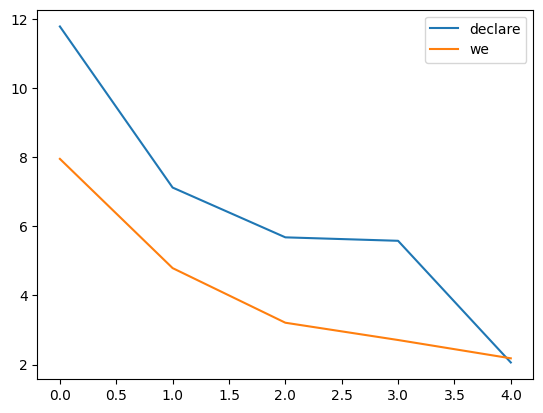

In [31]:
plt.plot(declare_predict_by_filter_error[1:], label="declare")
plt.plot(our_predict_errors_by_filter[1:], label="we")
plt.legend()
plt.show()

In [17]:
y_tests = np.array(y_tests)
y_pred_tests = np.array(y_pred_tests)

In [18]:
rr = y_pred_tests - y_tests

C:\Users\S.H.Jasbi\AppData\Local\Temp\ipykernel_2108\3059115527.py:8: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


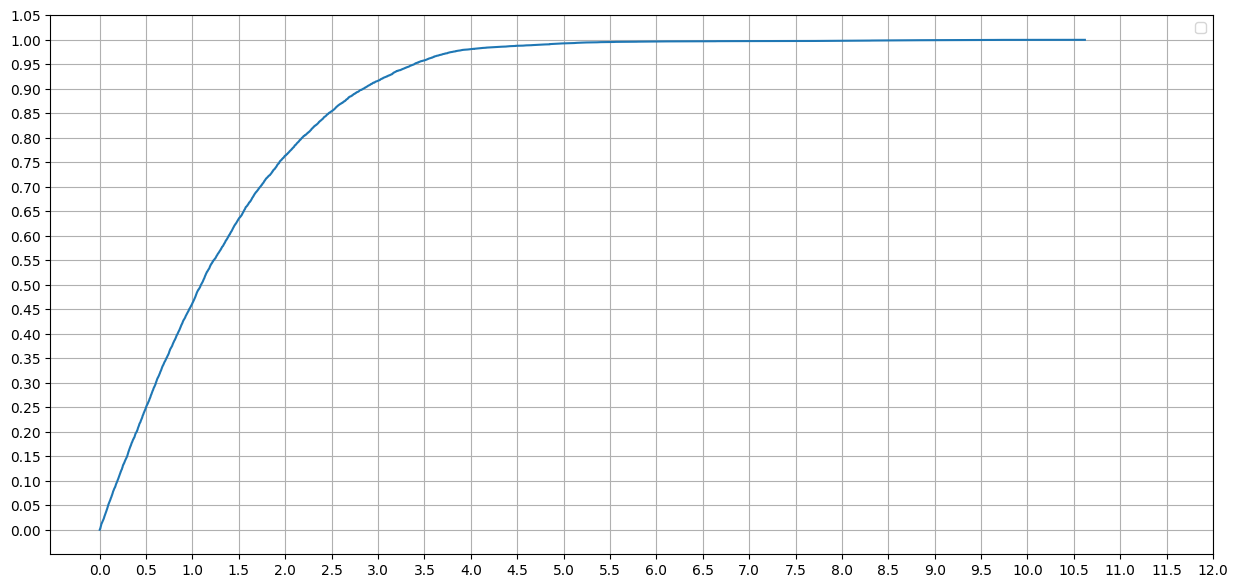

In [19]:
rrs = np.sort(np.abs(rr))
xxa = np.arange(len(rrs))/len(rrs)
plt.figure(figsize=(15,7))
plt.plot(rrs,xxa)
plt.grid()
plt.xticks(np.arange(0, 12.5, 0.5))
plt.yticks(np.arange(0, 1.1, 0.05))
plt.legend()
plt.show()